In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [3]:
iris = pd.read_csv("../data/flores_iris.csv")
iris = iris.sample(frac=1) # Embaralhando o dataset

In [4]:
'''
Antes de iniciar, vamos separar uma amostra de 10 dados para teste.
Esses dados não deveme estar no conjunto de treinamento.
Queremos que o modelo treinado saiba classificar dados que ele nunca viu.
'''
iris_teste = iris.sample(n=10)

In [5]:
'''
O seguinte filtro: ~iris["Id"].isin(iris_teste['Id'])
Retorna apenas as linhas onde o Id é diferente daqueles do dataframe 'iris_teste'
'''
iris = iris[~iris["Id"].isin(iris_teste['Id'])]

In [6]:
'''
Dataset de treinamento agora com N - 10 dados
'''
iris.shape

(140, 6)

In [7]:
iris.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [8]:
'''
Separando X (features) e y (classes)
'''

X = iris.drop('Species', axis=1)
y = iris['Species']

In [9]:
y.value_counts()

Species
Iris-setosa        48
Iris-versicolor    47
Iris-virginica     45
Name: count, dtype: int64

In [10]:
'''
Faremos uma classificação binária: 1 é Iris-setosa e 0 não
'''

y = y.map(
    {'Iris-setosa': 0,
     'Iris-versicolor': 1,
     'Iris-virginica': 0
     })

In [11]:
'''
Mesma transformação feita para o conjunto de treinamento.
'''

iris_teste['Species'] = iris_teste['Species'].map(
    {'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 0}
)

In [12]:
'''
Divisão entre conjunto de treinamento e validação
'''

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
102,103,7.1,3.0,5.9,2.1
84,85,5.4,3.0,4.5,1.5
35,36,5.0,3.2,1.2,0.2
52,53,6.9,3.1,4.9,1.5
5,6,5.4,3.9,1.7,0.4
...,...,...,...,...,...
95,96,5.7,3.0,4.2,1.2
79,80,5.7,2.6,3.5,1.0
34,35,4.9,3.1,1.5,0.1
104,105,6.5,3.0,5.8,2.2


In [14]:
y_train

102    0
84     1
35     0
52     1
5      0
      ..
95     1
79     1
34     0
104    0
23     0
Name: Species, Length: 112, dtype: int64

In [15]:
'''
Padronizando os dados
z = (x - media) / desvio_padrao
Especialmente útil no gradiente descendente, onde a escala dos dados pode afetar a convergência
Padronizando os dados para que tenham média 0 e desvio padrão 1

Isso é feito após a divisão treino teste
Data leakage: Se feito antes, calculamos estatísticas do conjunto
de treino que podem "vazar" para o conjunto de teste.
'''

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [16]:
'''
Criamos uma instância do modelo classificador.
Nesse caso é a regressão logística.
Chamamos a função "fit()", que realiza o treinamento do modelo em nosso conjunto de dados.
Perceba que as features X são passadas separadamente das labels y.
'''
model = LogisticRegression(solver="sag") # "sag" é o gradiente descendente
model.fit(X_train, y_train)

LogisticRegression(solver='sag')

In [17]:
'''
Uma vez treinado, podemos usar os dados de validação do treinamento
para ver a "qualidade" das respostas do modelo.

A função "predict()" realiza a predição das classes. Perceba
que passamos apenas o conjunto X_val, sem as labels. O modelo
irá retornar um array com as suas predições para cada linha.
'''

model.predict(X_val)

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1])

In [18]:
'''
Como possuímos o conjunto y_val que contém os valores reais
do conjunto de validação, podemos comparar ambos.
'''

preditos = model.predict(X_val)

In [19]:
'''
No classification report: Precisão -> TP/(TP+FP), Sensibilidade -> Recall TP/(TP+FN)
'''
print(classification_report(y_val, preditos))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        22
           1       0.83      0.83      0.83         6

    accuracy                           0.93        28
   macro avg       0.89      0.89      0.89        28
weighted avg       0.93      0.93      0.93        28



In [20]:
'''
Matriz de confusão
'''
cm = confusion_matrix(y_val, preditos)
cm

array([[21,  1],
       [ 1,  5]])

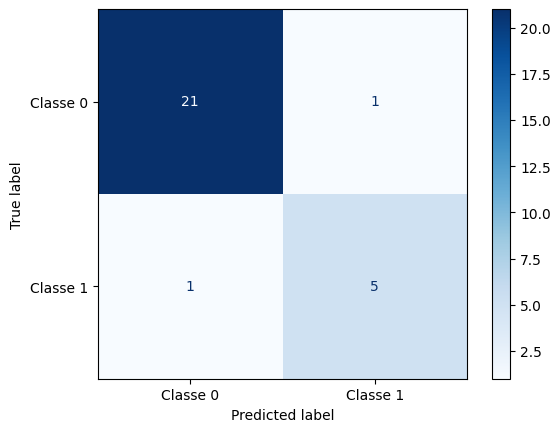

In [21]:
# ConfusionMatrixDisplay permite plotar com rótulos e cores
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues')
plt.show()

### Teste

In [22]:
real_test = iris_teste['Species']
iris_teste = iris_teste.drop("Species", axis=1)
iris_teste = scaler.fit_transform(iris_teste)
pred_test = model.predict(iris_teste)

compara = pd.DataFrame({"Predito": pred_test, "Real": real_test})

In [23]:
compara

,Predito,Real
7,0,0
103,1,0
123,0,0
32,0,0
70,1,1
111,1,0
131,0,0
81,1,1
99,0,1
117,0,0


### Experimento

Teste o modelo para predizer as outras duas espécies.
Por que os valores como predição e acurácia são diferentes?